Подготовка данных. Импорт zip архива.

In [ ]:
import os
import zipfile
import requests

def unzip_to_colab(zip_file_path, extract_path=None, delete_zip=False):
    """
    Unzips a zip archive in Google Colab.

    Args:
        zip_file_path (str): Path to the zip file (local in Colab or URL).
        extract_path (str, optional): Path to extract the archive to.
                                      If None, extracts to the current working directory.
                                      Defaults to None.
        delete_zip (bool, optional):  Delete the zip file after successful extraction.
                                         Defaults to False.
    """

    try:
        # 1. Check if the file exists
        if not os.path.exists(zip_file_path):
            print(f"Error: File '{zip_file_path}' not found.")
            return

        # 2. Determine the extraction path
        if extract_path is None:
            extract_path = os.getcwd()  # Current working directory
        else:
            # Create the directory if it doesn't exist
            os.makedirs(extract_path, exist_ok=True)


        # 3. Unzip the archive
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            zip_ref.extractall(extract_path)

        print(f"Zip archive '{zip_file_path}' successfully extracted to '{extract_path}'.")

        # 4. Delete the zip file (if specified)
        if delete_zip:
            try:
                os.remove(zip_file_path)
                print(f"Zip file '{zip_file_path}' deleted.")
            except OSError as e:
                print(f"Error deleting zip file: {e}")


    except zipfile.BadZipFile as e:
        print(f"Error: File '{zip_file_path}' is not a valid zip archive. Error: {e}")
    except FileNotFoundError as e:
        print(f"Error: File '{zip_file_path}' not found. Error: {e}")
    except Exception as e:
        print(f"An error occurred during extraction: {e}")


def download_and_save(url, save_path):
    """
    Downloads a file from a URL and saves it.
    """
    try:
        response = requests.get(url, stream=True)
        response.raise_for_status()  # Check that the request was successful

        with open(save_path, 'wb') as file:
            for chunk in response.iter_content(chunk_size=8192):
                file.write(chunk)
        print(f"File successfully downloaded and saved to: {save_path}")

    except requests.exceptions.RequestException as e:
        print(f"Error downloading file from '{url}': {e}")
        return False  # Indicate failure
    except Exception as e:
        print(f"An error occurred while downloading and saving the file: {e}")
        return False  # Indicate failure
    return True # Indicate success


# Optional: Check if the files were extracted successfully
# You can list the contents of the extraction directory to confirm.
# !ls "/content/sample_data" # Uncomment this line to list files in the directory


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Example usage
zip_file_path = '/content/sample_data/test5classes.zip'
extract_path = '/content/sample_data'

unzip_to_colab(zip_file_path, extract_path)


Zip archive '/content/sample_data/test5classes.zip' successfully extracted to '/content/sample_data'.


1.  Импорт библиотек: os для работы с файловой системой, random для перемешивания данных, shutil для копирования/перемещения файлов.
2.  *   DATA_DIR:  Путь к каталогу, содержащему папки с классами изображений.  Измените это, если ваши данные находятся в другом месте.  В Colab, '/content/sample_data' - это каталог по умолчанию, где Colab размещает примеры файлов.
    *   TRAIN_DIR: Путь к каталогу, где будет храниться тренировочная выборка.
    *   TEST_DIR:  Путь к каталогу, где будет храниться тестовая выборка.
    *   SPLIT_RATIO:  Соотношение тренировочной и тестовой выборки (от 0.0 до 1.0).  0.8 означает, что 80% данных будет использовано для обучения, а 20% - для тестирования.
    *   RANDOM_SEED:  Число, используемое для инициализации генератора случайных чисел.  Использование фиксированного RANDOM_SEED гарантирует, что при каждом запуске скрипта данные будут разделены одинаково (для воспроизводимости результатов).
3. целевые каталоги: os.makedirs(..., exist_ok=True) для создания каталогов TRAIN_DIR и TEST_DIR, если они еще не существуют.  exist_ok=True предотвращает ошибку, если каталоги уже существуют.
4.  random seed: random.seed(RANDOM_SEED) инициализирует генератор случайных чисел.
5.  список классов: Получает список подкаталогов в DATA_DIR, которые считаются классами.
6.  данные для каждого класса:  Цикл перебирает каждый класс:
    *   Получает список файлов изображений в каталоге класса.
    *   Вычисляет количество изображений для тренировочной и тестовой выборки.
    *   Перемешивает список файлов (random.shuffle(images)).  Это важно, чтобы избежать систематических смещений в данных.
    *   Разделяет список файлов на train_images и test_images.
7.  папки классов в тренировочном и тестовом каталогах: Создаются подкаталоги для каждого класса в каталогах TRAIN_DIR и TEST_DIR.
8.  файлы в соответствующие папки:  Файлы копируются из исходного каталога класса в соответствующие подкаталоги тренировочной и тестовой выборки.  shutil.copyfile(src_path, dst_path) копирует файл, сохраняя его в исходном месте.


In [ ]:
import os
import random
import shutil

# 1. Определите пути и параметры
DATA_DIR = '/content/sample_data/2 ¬½áßßá'  # Каталог с папками классов (SAMPLE_DATA по умолчанию в Colab)
TRAIN_DIR = '/content/train'      # Каталог для тренировочной выборки
TEST_DIR = '/content/test'        # Каталог для тестовой выборки
SPLIT_RATIO = 0.8                 # Соотношение тренировочной и тестовой выборки (80% train, 20% test)
RANDOM_SEED = 42                   # Для воспроизводимости результатов

# 2. Создайте целевые каталоги
os.makedirs(TRAIN_DIR, exist_ok=True)
os.makedirs(TEST_DIR, exist_ok=True)

# 3. Установите random seed для воспроизводимости
random.seed(RANDOM_SEED)

# 4. Получите список классов (подпапок в DATA_DIR)
classes = [d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))]
print(f"Обнаружены классы: {classes}")

# 5. Разделите данные для каждого класса
for class_name in classes:
    class_dir = os.path.join(DATA_DIR, class_name)
    images = os.listdir(class_dir)
    num_images = len(images)
    num_train = int(num_images * SPLIT_RATIO)

    # Перемешайте список файлов
    random.shuffle(images)

    # Разделите на тренировочную и тестовую выборки
    train_images = images[:num_train]
    test_images = images[num_train:]

    # 6. Создайте папки классов в тренировочном и тестовом каталогах
    train_class_dir = os.path.join(TRAIN_DIR, class_name)
    test_class_dir = os.path.join(TEST_DIR, class_name)
    os.makedirs(train_class_dir, exist_ok=True)
    os.makedirs(test_class_dir, exist_ok=True)

    # 7. Переместите файлы в соответствующие папки
    for image in train_images:
        src_path = os.path.join(class_dir, image)
        dst_path = os.path.join(train_class_dir, image)
        shutil.copyfile(src_path, dst_path)  # Используйте copyfile, чтобы не удалять файлы из исходной папки
        #os.rename(src_path, dst_path) #Если нужно переместить а не копировать файлы раскомментируйте эту строку и закоментируйте shutil.copyfile

    for image in test_images:
        src_path = os.path.join(class_dir, image)
        dst_path = os.path.join(test_class_dir, image)
        shutil.copyfile(src_path, dst_path)  # Используйте copyfile, чтобы не удалять файлы из исходной папки
        #os.rename(src_path, dst_path) #Если нужно переместить а не копировать файлы раскомментируйте эту строку и закоментируйте shutil.copyfile
    # 8. Выведите статистику
    print(f"Класс: {class_name}")
    print(f"  Всего изображений: {num_images}")
    print(f"  Тренировочных изображений: {len(train_images)}")
    print(f"  Тестовых изображений: {len(test_images)}")

print("Разделение данных завершено.")


Обнаружены классы: ['noall', 'all']
Класс: noall
  Всего изображений: 723
  Тренировочных изображений: 578
  Тестовых изображений: 145
Класс: all
  Всего изображений: 2076
  Тренировочных изображений: 1660
  Тестовых изображений: 416
Разделение данных завершено.


In [ ]:
# Example usage:
if __name__ == "__main__":
    ROOT_DIRECTORY = "/content/sample_data/2 class/validation/class2"  # Replace with your actual root directory path
    NEW_NAME_PREFIX = "image" # Desired prefix for the new file names
    START_INDEX = 1      # Starting index for the counter in the new names

    rename_files_in_folders(ROOT_DIRECTORY, NEW_NAME_PREFIX, START_INDEX)
    print("Renaming complete.")

Processing directory: /content/sample_data/2 class/validation/class2
Renamed 'Image__2025-02-27__11-42-28.tiff' to 'image_1.tiff'
Renamed 'Image__2025-02-27__11-17-34.tiff' to 'image_2.tiff'
Renamed 'Image__2025-02-27__11-17-03.tiff' to 'image_3.tiff'
Renamed 'Image__2025-02-27__11-42-51.tiff' to 'image_4.tiff'
Renaming complete.


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# Параметры
img_width, img_height = 400, 400  # Размер изображений
batch_size = 16  # Размер батча
train_data_dir = '/content/train'  # Путь к тренировочным данным
val_data_dir = '/content/train'  # Путь к валидационным данным
# Создание генераторов данных с аугментацией для обучения
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,  # Нормализация пикселей
    rotation_range=30,  # Вращение
    width_shift_range=0.2,  # Горизонтальный сдвиг
    height_shift_range=0.2,  # Вертикальный сдвиг
    shear_range=0.2,  # Искажение
    zoom_range=0.2,  # Зум
    horizontal_flip=True,  # Отражение по горизонтали
    fill_mode="nearest",
)


In [ ]:
val_datagen = ImageDataGenerator(rescale=1.0 / 255)  # Только нормализация
# Генератор данных для обучения
train_generator = train_datagen.flow_from_directory(
    train_data_dir,
    target_size=(img_width, img_height),
    color_mode = 'grayscale',
    batch_size=batch_size,
    class_mode="categorical",  # Используем "binary" для двух классов
)
# Генератор данных для валидации
val_generator = val_datagen.flow_from_directory(
    val_data_dir,
    target_size=(img_width, img_height),
    color_mode = 'grayscale',
    batch_size=batch_size,
    class_mode="categorical",
)
data_batch, labels_batch = train_generator.__next__()
# Проверка классов
print("Классы:", train_generator.class_indices)
# Вывод информации о пакете
print("Размер пакета изображений (data_batch.shape):", data_batch.shape)  # (batch_size, img_width, img_height, channels)
print("Размер пакета меток (labels_batch.shape):", labels_batch.shape)  # (batch_size,)  (или (batch_size, num_classes) для categorical)
print("Тип данных изображений (data_batch.dtype):", data_batch.dtype)
print("Тип данных меток (labels_batch.dtype):", labels_batch.dtype)
print("Метки в пакете (labels_batch):", labels_batch)  # Вывод меток

# Вывод информации о генераторе
print("\nАтрибуты train_generator:")
print("  .directory:", train_generator.directory)  # Корневой каталог
print("  .image_shape:", train_generator.image_shape)  # Размеры изображения (высота, ширина, каналы)
print("  .num_classes:", train_generator.num_classes)  # Количество классов
print("  .class_indices:", train_generator.class_indices)  # Словарь сопоставления имен классов с индексами
print("  .samples:", train_generator.samples)  # Общее количество образцов
print("  .batch_size:", train_generator.batch_size)  # Размер пакета
print("  .target_size:", train_generator.target_size)  # Целевой размер изображения
print("  .color_mode:", train_generator.color_mode)  # Цветовой режим
print("  .class_mode:", train_generator.class_mode)  # Режим классов
print("  .shuffle:", train_generator.shuffle)  # Перемешивание


Found 2238 images belonging to 2 classes.
Found 2238 images belonging to 2 classes.
Классы: {'all': 0, 'noall': 1}
Размер пакета изображений (data_batch.shape): (16, 400, 400, 1)
Размер пакета меток (labels_batch.shape): (16, 2)
Тип данных изображений (data_batch.dtype): float32
Тип данных меток (labels_batch.dtype): float32
Метки в пакете (labels_batch): [[1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [1. 0.]]

Атрибуты train_generator:
  .directory: /content/train
  .image_shape: (400, 400, 1)
  .num_classes: 2
  .class_indices: {'all': 0, 'noall': 1}
  .samples: 2238
  .batch_size: 16
  .target_size: (400, 400)
  .color_mode: grayscale
  .class_mode: categorical
  .shuffle: True


Вывод информации об образце из DataGeneration


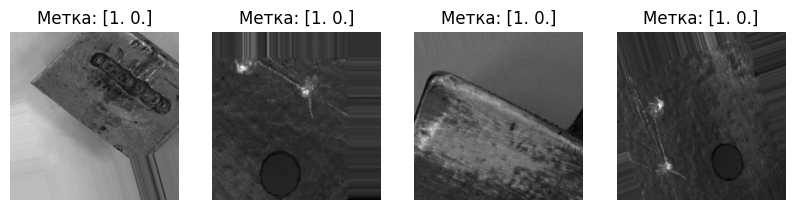

In [ ]:
import matplotlib.pyplot as plt
BATCH_SIZE = 4
num_images_to_display = min(BATCH_SIZE, 4)

plt.figure(figsize=(10, 5))
for i in range(num_images_to_display):
    plt.subplot(1, num_images_to_display, i + 1)
    image = data_batch[i]
    label = labels_batch[i]

    # Отображение изображения (с учетом цветового режима)
    if train_generator.color_mode == 'grayscale':
        plt.imshow(image[:, :, 0], cmap='gray') # Отображаем только один канал для grayscale
    else:
        plt.imshow(image)

    plt.title(f"Метка: {label}")
    plt.axis('off')

plt.show()

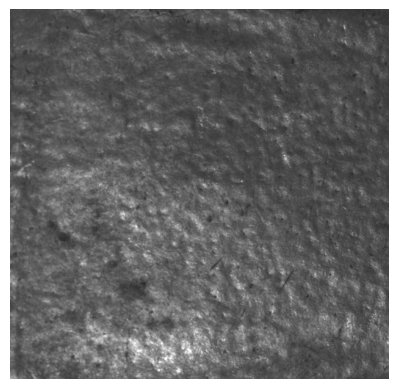

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
image_path = '/content/test/noall/15.tif'

# Загрузите изображение
img = mpimg.imread(image_path)

# Выведите изображение
plt.imshow(img)
plt.axis('off')  # Отключить оси
plt.show()

увеличивает количество изображений в обучающем наборе за счёт аугментации.
Нормализует пиксели: преобразует значения в диапазон [0,1].
Создаёт генераторы данных: train_generator и val_generator, которые можно использовать при обучении модели.
изменить режим классификации, поменять class_mode="binary" на "categorical", если у вас более двух классов.


2. Создание моделей
2.1 Модель классификации (CNN)


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
# Создание модели классификации
model = Sequential(),
inputs = Input(shape=(400, 400, 1))
x = Conv2D(32, 3, activation="relu", padding="same")(inputs)
x = MaxPooling2D(pool_size=2)(x)
x = Conv2D(64, 3, activation="relu", padding="same")(x)
x = MaxPooling2D(pool_size=2)(x)
x = Flatten()(x)
x = Dense(64, activation="relu")(x)

    # Выход: [x, y, width, height, class_id]
output = Dense(2, activation="softmax")(x)
model = tf.keras.Model(inputs, output)
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 400, 400, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 400, 400, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 200, 200, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 200, 200, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 100, 100, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 640000)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │    40,960,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,979,010 (156.32 MB)

 Trainable params: 40,979,010 (156.32 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from keras.callbacks import ModelCheckpoint
checkpoint = ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True)
history = model.fit(train_generator, epochs=10, batch_size=32, validation_data=val_generator, callbacks=[checkpoint])

Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.7429 - loss: 0.5237

140/140 ━━━━━━━━━━━━━━━━━━━━ 881s 6s/step - accuracy: 0.7431 - loss: 0.5232 - val_accuracy: 0.8499 - val_loss: 0.3022
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 847s 6s/step - accuracy: 0.8609 - loss: 0.3192 - val_accuracy: 0.8561 - val_loss: 0.3330
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.8513 - loss: 0.3548

140/140 ━━━━━━━━━━━━━━━━━━━━ 846s 6s/step - accuracy: 0.8513 - loss: 0.3545 - val_accuracy: 0.8713 - val_loss: 0.2651
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 844s 6s/step - accuracy: 0.8633 - loss: 0.2866 - val_accuracy: 0.8637 - val_loss: 0.3734
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 839s 6s/step - accuracy: 0.8290 - loss: 0.3172 - val_accuracy: 0.8753 - val_loss: 0.2906
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 839s 6s/step - accuracy: 0.8364 - loss: 0.4000 - val_accuracy: 0.8825 - val_loss: 0.2817
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 861s 6s/step - accuracy: 0.8327 - loss: 0.3185 - val_accuracy: 0.8601 - val_loss: 0.4697
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.7950 - loss: 0.4237

140/140 ━━━━━━━━━━━━━━━━━━━━ 840s 6s/step - accuracy: 0.7952 - loss: 0.4234 - val_accuracy: 0.8870 - val_loss: 0.2532
Epoch 9/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.8673 - loss: 0.2854

140/140 ━━━━━━━━━━━━━━━━━━━━ 841s 6s/step - accuracy: 0.8673 - loss: 0.2854 - val_accuracy: 0.8914 - val_loss: 0.2202
Epoch 10/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 861s 6s/step - accuracy: 0.8721 - loss: 0.2771 - val_accuracy: 0.8660 - val_loss: 0.2783


In [ ]:
# Оценка модели на тестовых данных
val_generator = val_datagen.flow_from_directory(
    '/content/test',  # Укажите путь к вашим тестовым данным
    target_size=(img_height, img_width),
    batch_size=batch_size,
    color_mode = 'grayscale',
    class_mode='categorical',
    shuffle=False  # Важно для правильного вычисления метрик
)

Found 561 images belonging to 2 classes.


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score

# 1. Получение предсказаний от модели
predictions = model.predict(val_generator)

# 2. Получение истинных меток (ground truth) из val_generator

true_classes = val_generator.classes  # Если это DirectoryIterator

# 3. Преобразование вероятностей в классы (если модель предсказывает вероятности)

predicted_classes = np.argmax(predictions, axis=1)

# 4. Вычисление accuracy
accuracy = accuracy_score(true_classes, predicted_classes)

# 5. Вывод метрики
print(f"Accuracy: {accuracy}")

36/36 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step
Accuracy: 0.8770053475935828


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Вариант 1: Расчет метрик для каждого класса отдельно (average=None)
precision = precision_score(true_classes, predicted_classes, average=None)
recall = recall_score(true_classes, predicted_classes, average=None)
f1 = f1_score(true_classes, predicted_classes, average=None)

print("Precision per class:", precision)
print("Recall per class:", recall)
print("F1-score per class:", f1)

# Общие метрики и отчет о классификации (рекомендуется использовать classification_report)
conf_matrix = confusion_matrix(true_classes, predicted_classes)  # Матрица ошибок
class_report = classification_report(true_classes, predicted_classes) # Отчет о классификации

print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", class_report)


Precision per class: [0.93483709 0.7345679 ]
Recall per class: [0.89663462 0.82068966]
F1-score per class: [0.91533742 0.7752443 ]
Confusion Matrix:
 [[373  43]
 [ 26 119]]
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.90      0.92       416
           1       0.73      0.82      0.78       145

    accuracy                           0.88       561
   macro avg       0.83      0.86      0.85       561
weighted avg       0.88      0.88      0.88       561



In [ ]:
# Вариант 2: Использование 'micro' усреднения (подходит, когда важен общий результат)
precision_micro = precision_score(true_classes, predicted_classes, average='micro')
recall_micro = recall_score(true_classes, predicted_classes, average='micro')
f1_micro = f1_score(true_classes, predicted_classes, average='micro')

print("Micro-averaged precision:", precision_micro)
print("Micro-averaged recall:", recall_micro)
print("Micro-averaged F1-score:", f1_micro)

Micro-averaged precision: 0.8770053475935828
Micro-averaged recall: 0.8770053475935828
Micro-averaged F1-score: 0.8770053475935828


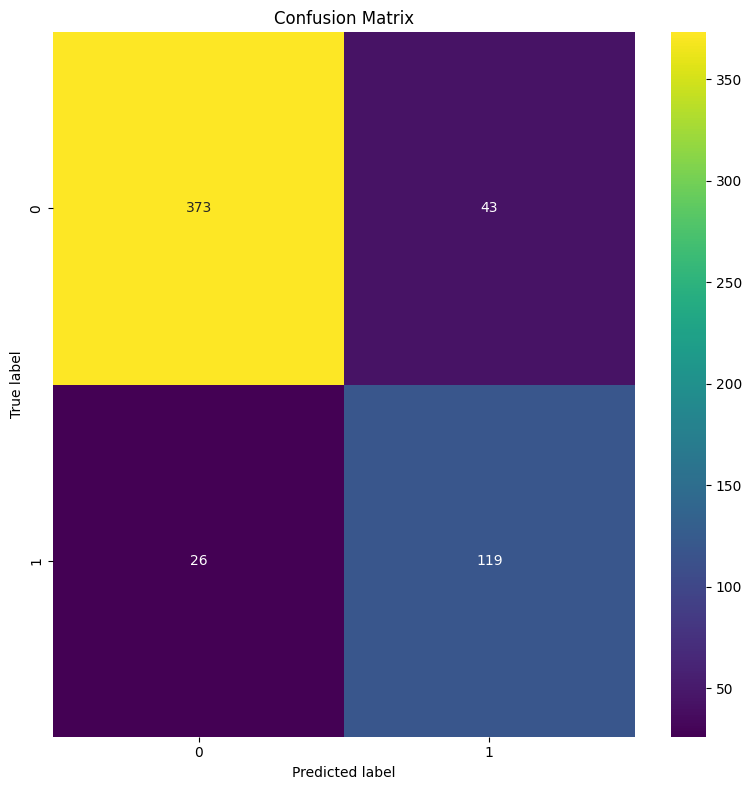

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(true_classes, predicted_classes, class_name=True, title='Confusion Matrix', cmap='viridis'):
    """
    Выводит матрицу соответствия в виде тепловой карты.

    Аргументы:
        y_true:  Истинные метки классов (numpy array или list).
        y_pred:  Предсказанные метки классов (numpy array или list).
        class_names:  Список имен классов (необязательно).  Если не указан,
                       будут использоваться числовые метки.
        title:  Заголовок графика (по умолчанию 'Confusion Matrix').
        cmap:  Цветовая схема для тепловой карты (по умолчанию 'Blues').  См.
               https://matplotlib.org/stable/tutorials/colors/colormaps.html для
               доступных вариантов.
    """

    cm = confusion_matrix(true_classes, predicted_classes)

    # if class_name is None:
    #     class_name = np.arange(cm.shape[0]) # Создаем числовые метки, если не предоставлены

    plt.figure(figsize=(8, 8))  # Размер фигуры (можно изменить)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, xticklabels=class_name, yticklabels=class_name) # fmt='d' для целых чисел
    plt.title(title)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()  # Автоматическая корректировка, чтобы метки не обрезались
    plt.show()

plot_confusion_matrix(true_classes, predicted_classes, cmap='viridis')


In [ ]:



# Вариант 3: Использование 'macro' усреднения (подходит, когда все классы одинаково важны)
precision_macro = precision_score(true_classes, predicted_classes, average='macro')
recall_macro = recall_score(true_classes, predicted_classes, average='macro')
f1_macro = f1_score(true_classes, predicted_classes, average='macro')

print("Macro-averaged precision:", precision_macro)
print("Macro-averaged recall:", recall_macro)
print("Macro-averaged F1-score:", f1_macro)


Macro-averaged precision: 0.8347024969831988
Macro-averaged recall: 0.8586621352785146
Macro-averaged F1-score: 0.8452908614935752


In [ ]:


# Вариант 4: Использование 'weighted' усреднения (учитывает количество экземпляров в каждом классе)
precision_weighted = precision_score(true_classes, predicted_classes, average='weighted')
recall_weighted = recall_score(true_classes, predicted_classes, average='weighted')
f1_weighted = f1_score(true_classes, predicted_classes, average='weighted')

print("Weighted-averaged precision:", precision_weighted)
print("Weighted-averaged recall:", recall_weighted)
print("Weighted-averaged F1-score:", f1_weighted)

Weighted-averaged precision: 0.8830741109722877
Weighted-averaged recall: 0.8770053475935828
Weighted-averaged F1-score: 0.8791279706790165


In [ ]:
print(f'Accuracy: {accuracy}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1 Score: {f1}')
print('Confusion Matrix:')
print(conf_matrix)
print('Classification Report:')
print(class_report)

Accuracy: 0.8770053475935828
Precision: [0.93483709 0.7345679 ]
Recall: [0.89663462 0.82068966]
F1 Score: [0.91533742 0.7752443 ]
Confusion Matrix:
[[373  43]
 [ 26 119]]
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.90      0.92       416
           1       0.73      0.82      0.78       145

    accuracy                           0.88       561
   macro avg       0.83      0.86      0.85       561
weighted avg       0.88      0.88      0.88       561



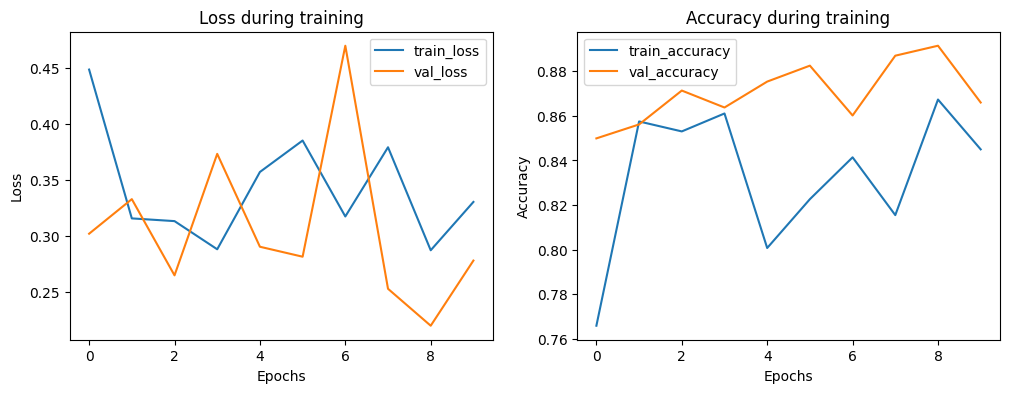

In [ ]:
# Графики обучения loss и accuracy
plt.figure(figsize=(12, 4))

# График потерь (loss)
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss during training')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# График точности (accuracy)
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Accuracy during training')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [ ]:
IMG_WIDTH = 400
IMG_HEIGHT = 400
BATCH_SIZE = 16
NUM_CLASSES = 2  # Два класса
DIRECTORY = '/content/train'  # Замените на фактический путь (один каталог)

# Определение генератора данных
datagen = ImageDataGenerator(rescale=1./255)  # Масштабирование изображений

train_generator = datagen.flow_from_directory(
    DIRECTORY,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    color_mode='grayscale',  # Убедитесь, что соответствует вашим изображениям
    class_mode='categorical',  # Использовать 'binary', если у вас 2 класса
    shuffle=True  # Обычно рекомендуется перемешивать данные
)

Found 2238 images belonging to 2 classes.


Перенос обучения

In [ ]:
import os
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.regularizers import l2
from PIL import Image
import matplotlib.pyplot as plt
from keras.optimizers import Adam

In [ ]:
  !pip install opencv-python tqdm

Заменить пути:
  - Заменить "path/to/your/train_grayscale_images" и "path/to/your/test_grayscale_images" на фактический путь к папкам с grayscale изображениями. Эти папки должны содержать подпапки для каждого класса.
  - Заменить "path/to/your/train_rgb_images" и "path/to/your/test_rgb_images" на путь, где надо сохранить преобразованные RGB изображения. Код создаст эти папки (и подпапки классов), если они не существуют.

Функция grayscale_to_rgb(input_dir, output_dir):
  - Принимает пути к входной и выходной папкам.
  - Проверяет существование входной папки.
  - Создает выходную папку (и подпапки классов), если она не существует.
  - Перебирает подпапки (классы) во входной папке.
  - Перебирает файлы изображений в каждой папке класса.
  - Для каждого изображения:
   - Читает изображение в grayscale с помощью cv2.imread(image_path, cv2.IMREAD_GRAYSCALE).
   - Преобразует grayscale изображение в RGB с помощью cv2.cvtColor(img_gray, cv2.COLOR_GRAY2RGB).
   - Сохраняет RGB изображение с помощью cv2.imwrite(output_path, img_rgb).
  - Обрабатывает исключения (ошибки при чтении или записи изображений).

• Структура папок: изображения были организованы в папки train и test, а внутри каждой из этих папок были подпапки для каждого класса. Например:

In [ ]:
import os

def create_directory(directory_path):
    """Создает директорию, если она еще не существует.

    Args:
        directory_path (str): Путь к директории, которую нужно создать.
    """
    if not os.path.exists(directory_path):
        try:
            os.makedirs(directory_path)
            print(f"Директория '{directory_path}' успешно создана.")
        except OSError as e:
            print(f"Ошибка при создании директории '{directory_path}': {e}")
    else:
        print(f"Директория '{directory_path}' уже существует.")


# Определяем пути для папок
train_grayscale_path = "train_rgb_images"
test_rgb_path = "test_rgb_images"

# Создаем папки
create_directory(train_grayscale_path)
create_directory(test_rgb_path)

print("Готово.")

Директория 'train_rgb_images' успешно создана.
Директория 'test_rgb_images' успешно создана.
Готово.


In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm  # Для отображения прогресса

def grayscale_to_rgb(input_dir, output_dir):
    """
    Преобразует изображения в grayscale в RGB формат, сохраняя структуру папок.

    Args:
        input_dir (str): Путь к папке с изображениями в grayscale, рассортированными по классам.
                         Структура должна быть: input_dir/класс1/изображения, input_dir/класс2/изображения, ...
        output_dir (str): Путь к папке, где будут сохранены преобразованные изображения в RGB.
                          Будет создана аналогичная структура папок.
    """

    # Проверяем, существует ли входная папка
    if not os.path.exists(input_dir):
        print(f"Ошибка: Входная папка '{input_dir}' не существует.")
        return

    # Создаем выходную папку, если она не существует
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    # Получаем список классов (подпапок) во входной папке
    classes = os.listdir(input_dir)
    print(f"Найдены классы: {classes}")

    for class_name in classes:
        class_input_dir = os.path.join(input_dir, class_name)
        class_output_dir = os.path.join(output_dir, class_name)

        # Проверяем, что это действительно папка
        if not os.path.isdir(class_input_dir):
            print(f"Предупреждение: '{class_input_dir}' не является папкой. Пропускаем.")
            continue

        # Создаем папку класса в выходной папке
        if not os.path.exists(class_output_dir):
            os.makedirs(class_output_dir)

        # Получаем список файлов изображений в папке класса
        image_files = os.listdir(class_input_dir)

        print(f"Обработка класса: {class_name}")
        for image_file in tqdm(image_files, desc=f"Преобразование изображений в {class_name}"):
            image_path = os.path.join(class_input_dir, image_file)
            output_path = os.path.join(class_output_dir, image_file)

            try:
                # Читаем изображение в grayscale
                img_gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

                # Проверяем, успешно ли прочитано изображение
                if img_gray is None:
                    print(f"Ошибка: Не удалось прочитать изображение '{image_path}'. Пропускаем.")
                    continue

                # Преобразуем в RGB
                img_rgb = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2RGB)

                # Сохраняем изображение в RGB
                cv2.imwrite(output_path, img_rgb)

            except Exception as e:
                print(f"Ошибка при обработке изображения '{image_path}': {e}. Пропускаем.")




In [ ]:
train_input_dir = "/content/train"  # Замените на путь к вашей папке train
train_output_dir = "/content/train_rgb_images"  # Замените на путь, куда сохранить train RGB
test_input_dir = "/content/test"  # Замените на путь к вашей папке test
test_output_dir = "/content/test_rgb_images"  # Замените на путь, куда сохранить test RGB

grayscale_to_rgb(train_input_dir, train_output_dir)
grayscale_to_rgb(test_input_dir, test_output_dir)

print("Преобразование завершено.")


Найдены классы: ['noall', 'all']
Обработка класса: noall


Преобразование изображений в noall: 100%|██████████| 578/578 [00:01<00:00, 362.41it/s]


Обработка класса: all


Преобразование изображений в all: 100%|██████████| 1660/1660 [00:06<00:00, 252.89it/s]


Найдены классы: ['noall', 'all']
Обработка класса: noall


Преобразование изображений в noall: 100%|██████████| 145/145 [00:00<00:00, 363.51it/s]


Обработка класса: all


Преобразование изображений в all: 100%|██████████| 416/416 [00:01<00:00, 306.39it/s]

Преобразование завершено.



1.
Загрузка обученной модели Указав аргумент include_top=False, вы загружаете сеть, которая не включает слои классификации вверху

In [ ]:
# Загрузка модели MobileNetV2
base_model = MobileNetV2    (include_top=False, weights='imagenet', input_shape=(224, 224, 3))

base_model.summary()


for layer in base_model.layers:
    layer.trainable = False
# Добавление своих классифицирующих слоев (поверх VGG19)

# flattened превращает выходы сверточных слоев в одномерный вектор как в прошлой работе

# Преобразуем двумерные данные в вектор
keras.layers.Flatten(),

# Instantiate the sequential model and add the model:
model = Sequential()
model.add(base_model)

# Add the custom layers atop the model:
model.add(Flatten(name='flattened'))
model.add(Dropout(0.8))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(2, activation='softmax', kernel_regularizer=l2(0.01), name='predictions'))
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])
# model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])


Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 2,223,872 (8.48 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [ ]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flattened (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │     1,605,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,632,226 (82.52 MB)

 Trainable params: 1,607,842 (6.13 MB)

 Non-trainable params: 20,024,384 (76.39 MB)

In [ ]:
img_width, img_height = 224, 224  # Размер изображений
batch_size = 32  # Размер батча
train_dir = '/content/train_rgb_images'  # Путь к тренировочным данным
val_dir = '/content/test_rgb_images'  # Путь к валидационным данным
#Создайте экземпляры двух классов генераторов изображений:
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=30,        # случайные повороты на +-30 градусов
    horizontal_flip=True,     # случайное отражение по горизонтали
    fill_mode='reflect',       # заполнение пустых мест отражением краёв
    validation_split=0.2
)

valid_datagen = ImageDataGenerator(
    rescale=1.0/255,
    validation_split=0.2
)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    directory=train_dir,
    target_size=(224, 224),
    classes=['all', 'noall'],
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=True,
    seed=42,
    )

valid_generator = valid_datagen.flow_from_directory(
    directory=val_dir,
    target_size=(224, 224),
    classes=['all', 'noall'],
    class_mode='categorical',
    batch_size=batch_size,
    )

Found 2238 images belonging to 2 classes.
Found 561 images belonging to 2 classes.


In [ ]:
data_batch, labels_batch = train_generator.__next__()
# Проверка классов
print("Классы:", train_generator.class_indices)
# Вывод информации о пакете
print("Размер пакета изображений (data_batch.shape):", data_batch.shape)  # (batch_size, img_width, img_height, channels)
print("Размер пакета меток (labels_batch.shape):", labels_batch.shape)  # (batch_size,)  (или (batch_size, num_classes) для categorical)
print("Тип данных изображений (data_batch.dtype):", data_batch.dtype)
print("Тип данных меток (labels_batch.dtype):", labels_batch.dtype)
print("Метки в пакете (labels_batch):", labels_batch)  # Вывод меток

# Вывод информации о генераторе
print("\nАтрибуты train_generator:")
print("  .directory:", train_generator.directory)  # Корневой каталог
print("  .image_shape:", train_generator.image_shape)  # Размеры изображения (высота, ширина, каналы)
print("  .num_classes:", train_generator.num_classes)  # Количество классов
print("  .class_indices:", train_generator.class_indices)  # Словарь сопоставления имен классов с индексами
print("  .samples:", train_generator.samples)  # Общее количество образцов
print("  .batch_size:", train_generator.batch_size)  # Размер пакета
print("  .target_size:", train_generator.target_size)  # Целевой размер изображения
print("  .color_mode:", train_generator.color_mode)  # Цветовой режим
print("  .class_mode:", train_generator.class_mode)  # Режим классов
print("  .shuffle:", train_generator.shuffle)  # Перемешивание

Классы: {'all': 0, 'noall': 1}
Размер пакета изображений (data_batch.shape): (32, 224, 224, 3)
Размер пакета меток (labels_batch.shape): (32, 2)
Тип данных изображений (data_batch.dtype): float32
Тип данных меток (labels_batch.dtype): float32
Метки в пакете (labels_batch): [[0. 1.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [1. 0.]]

Атрибуты train_generator:
  .directory: /content/train_rgb_images
  .image_shape: (224, 224, 3)
  .num_classes: 2
  .class_indices: {'all': 0, 'noall': 1}
  .samples: 2238
  .batch_size: 32
  .target_size: (224, 224)
  .color_mode: rgb
  .class_mode: categorical
  .shuffle: True


In [ ]:
# Проверяем форму первого пакета
x_batch, y_batch = next(train_generator)
print("Shape of x_batch:", x_batch.shape)  # Должно быть (batch_size, 224, 224, num_channels)
x_batch, y_batch = next(valid_generator)
print("Shape of x_batch:", x_batch.shape)

Shape of x_batch: (32, 224, 224, 3)
Shape of x_batch: (32, 224, 224, 3)


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG19
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam


In [ ]:

# Создание модели
base_model = VGG19(weights='imagenet', include_top=False, input_shape=(img_width, img_height, 3))
base_model.trainable = False # Замораживаем веса базовой модели
num_classes = 2
model = Sequential()
model.add(base_model)

# Add the custom layers atop the model:
model.add(Flatten(name='flattened'))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax', kernel_regularizer=l2(0.015), name='predictions'))
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flattened (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │     1,605,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,632,226 (82.52 MB)

 Trainable params: 1,607,842 (6.13 MB)

 Non-trainable params: 20,024,384 (76.39 MB)

In [ ]:
from keras.callbacks import ModelCheckpoint
checkpoint = ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True)
# Компиляция модели
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy', # categorical_crossentropy для one-hot encoding
              metrics=['accuracy'])
checkpoint = ModelCheckpoint('best_model_VGG.h5', monitor='val_loss', save_best_only=True)
# Обучение модели
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    epochs=10,
    validation_data=valid_generator,
    validation_steps=valid_generator.samples // batch_size,
    callbacks=[checkpoint]
)

print("Обучение завершено.")

Epoch 1/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 26s/step - accuracy: 0.5510 - loss: 0.9968 

69/69 ━━━━━━━━━━━━━━━━━━━━ 2192s 32s/step - accuracy: 0.5517 - loss: 0.9944 - val_accuracy: 0.7445 - val_loss: 0.5867
Epoch 2/10
 1/69 ━━━━━━━━━━━━━━━━━━━━ 29:16 26s/step - accuracy: 0.5938 - loss: 0.6980

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


69/69 ━━━━━━━━━━━━━━━━━━━━ 451s 6s/step - accuracy: 0.5938 - loss: 0.6980 - val_accuracy: 0.7390 - val_loss: 0.5914
Epoch 3/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 25s/step - accuracy: 0.6466 - loss: 0.6931 

69/69 ━━━━━━━━━━━━━━━━━━━━ 2203s 32s/step - accuracy: 0.6466 - loss: 0.6930 - val_accuracy: 0.7371 - val_loss: 0.5442
Epoch 4/10
 1/69 ━━━━━━━━━━━━━━━━━━━━ 26:31 23s/step - accuracy: 0.6875 - loss: 0.7287

69/69 ━━━━━━━━━━━━━━━━━━━━ 502s 7s/step - accuracy: 0.6875 - loss: 0.7287 - val_accuracy: 0.7408 - val_loss: 0.5379
Epoch 5/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 25s/step - accuracy: 0.6865 - loss: 0.6351 

69/69 ━━━━━━━━━━━━━━━━━━━━ 2241s 33s/step - accuracy: 0.6865 - loss: 0.6349 - val_accuracy: 0.7518 - val_loss: 0.4636
Epoch 6/10
 1/69 ━━━━━━━━━━━━━━━━━━━━ 27:25 24s/step - accuracy: 0.7812 - loss: 0.6175

69/69 ━━━━━━━━━━━━━━━━━━━━ 450s 6s/step - accuracy: 0.7812 - loss: 0.6175 - val_accuracy: 0.7555 - val_loss: 0.4615
Epoch 7/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 25s/step - accuracy: 0.7118 - loss: 0.6009 

69/69 ━━━━━━━━━━━━━━━━━━━━ 2242s 32s/step - accuracy: 0.7121 - loss: 0.6005 - val_accuracy: 0.8860 - val_loss: 0.4267
Epoch 8/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 452s 6s/step - accuracy: 0.7500 - loss: 0.5733 - val_accuracy: 0.8860 - val_loss: 0.4269
Epoch 9/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 26s/step - accuracy: 0.7435 - loss: 0.5650 

69/69 ━━━━━━━━━━━━━━━━━━━━ 2248s 32s/step - accuracy: 0.7437 - loss: 0.5646 - val_accuracy: 0.8842 - val_loss: 0.3599
Epoch 10/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 501s 7s/step - accuracy: 0.8750 - loss: 0.4155 - val_accuracy: 0.8768 - val_loss: 0.3690
Обучение завершено.


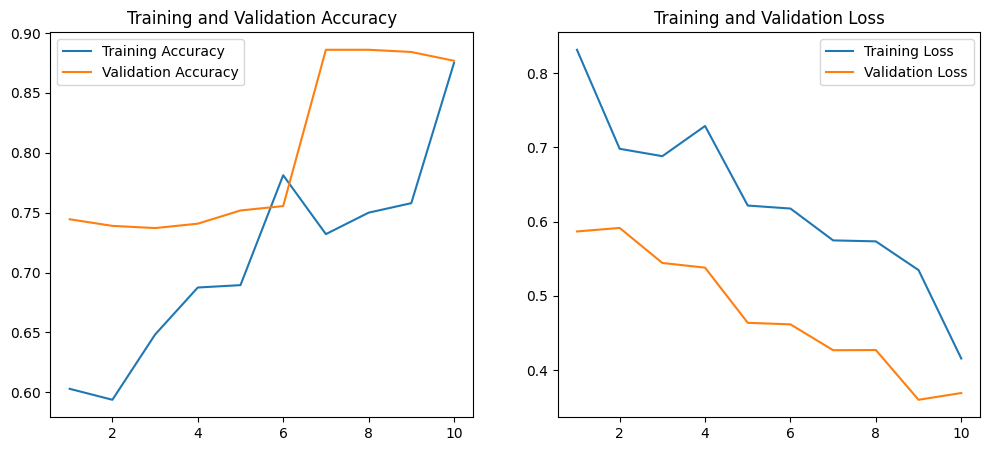

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Training and Validation Loss')

plt.show()

In [ ]:
# Оценка модели на тестовых данных

valid_generator = valid_datagen.flow_from_directory(
    directory=val_dir,
    target_size=(224, 224),
    classes=['all', 'noall'],
    class_mode='categorical',
    batch_size=batch_size,
    shuffle = False  # Важно для правильного вычисления метрик
)

Found 561 images belonging to 2 classes.


In [ ]:
# 1. Получение предсказаний от модели
predictions = model.predict(valid_generator)

# 2. Получение истинных меток (ground truth) из val_generator

true_classes = valid_generator.classes  # Если это DirectoryIterator

# 3. Преобразование вероятностей в классы (если модель предсказывает вероятности)

predicted_classes = np.argmax(predictions, axis=1)

# 4. Вычисление accuracy
accuracy = accuracy_score(true_classes, predicted_classes)

# 5. Вывод метрики
print(f"Accuracy: {accuracy}")

18/18 ━━━━━━━━━━━━━━━━━━━━ 440s 24s/step
Accuracy: 0.8770053475935828


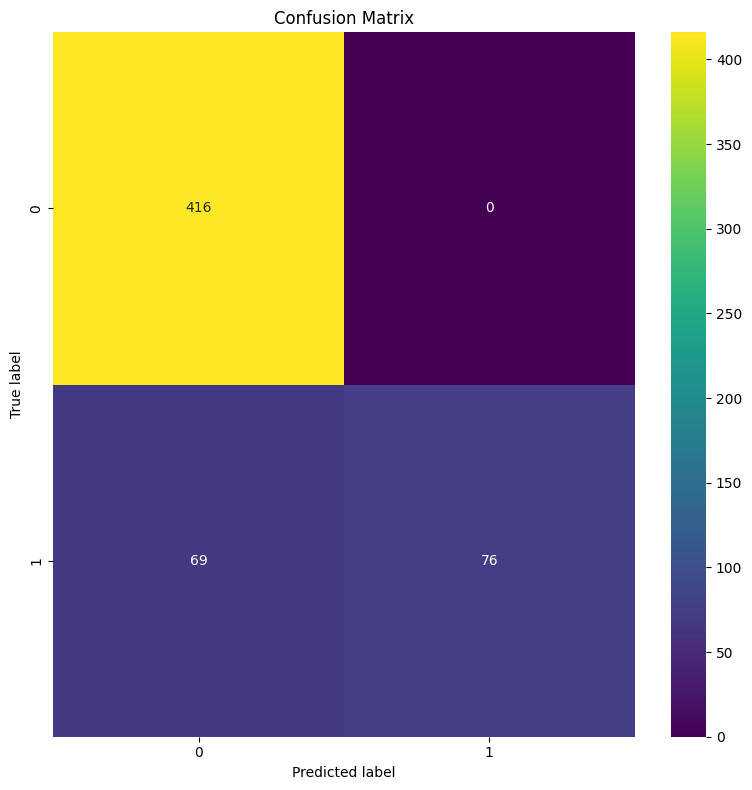

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(true_classes, predicted_classes, class_name=True, title='Confusion Matrix', cmap='viridis'):
    """
    Выводит матрицу соответствия в виде тепловой карты.

    Аргументы:
        y_true:  Истинные метки классов (numpy array или list).
        y_pred:  Предсказанные метки классов (numpy array или list).
        class_names:  Список имен классов (необязательно).  Если не указан,
                       будут использоваться числовые метки.
        title:  Заголовок графика (по умолчанию 'Confusion Matrix').
        cmap:  Цветовая схема для тепловой карты (по умолчанию 'Blues').  См.
               https://matplotlib.org/stable/tutorials/colors/colormaps.html для
               доступных вариантов.
    """

    cm = confusion_matrix(true_classes, predicted_classes)

    # if class_name is None:
    #     class_name = np.arange(cm.shape[0]) # Создаем числовые метки, если не предоставлены

    plt.figure(figsize=(8, 8))  # Размер фигуры (можно изменить)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, xticklabels=class_name, yticklabels=class_name) # fmt='d' для целых чисел
    plt.title(title)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()  # Автоматическая корректировка, чтобы метки не обрезались
    plt.show()

plot_confusion_matrix(true_classes, predicted_classes, cmap='viridis')

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Вариант 1: Расчет метрик для каждого класса отдельно (average=None)
precision = precision_score(true_classes, predicted_classes, average=None)
recall = recall_score(true_classes, predicted_classes, average=None)
f1 = f1_score(true_classes, predicted_classes, average=None)

print("Precision per class:", precision)
print("Recall per class:", recall)
print("F1-score per class:", f1)

# Общие метрики и отчет о классификации (рекомендуется использовать classification_report)
conf_matrix = confusion_matrix(true_classes, predicted_classes)  # Матрица ошибок
class_report = classification_report(true_classes, predicted_classes) # Отчет о классификации

print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", class_report)


Precision per class: [0.85773196 1.        ]
Recall per class: [1.         0.52413793]
F1-score per class: [0.92341842 0.68778281]
Confusion Matrix:
 [[416   0]
 [ 69  76]]
Classification Report:
               precision    recall  f1-score   support

           0       0.86      1.00      0.92       416
           1       1.00      0.52      0.69       145

    accuracy                           0.88       561
   macro avg       0.93      0.76      0.81       561
weighted avg       0.89      0.88      0.86       561



In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix

# Получаем предсказания
y_pred = model.predict(valid_generator, steps=len(valid_generator))
y_pred = np.argmax(y_pred, axis=1) # Преобразуем one-hot encoding в метки классов

# Получаем истинные метки классов
y_true = valid_generator.classes

# Вычисляем матрицу соответствия
cm = confusion_matrix(y_true, y_pred)
print(cm)

18/18 ━━━━━━━━━━━━━━━━━━━━ 472s 26s/step
[[416   0]
 [ 69  76]]


In [ ]:
# Вариант 2: Использование 'micro' усреднения (подходит, когда важен общий результат)
precision_micro = precision_score(true_classes, predicted_classes, average='micro')
recall_micro = recall_score(true_classes, predicted_classes, average='micro')
f1_micro = f1_score(true_classes, predicted_classes, average='micro')

print("Micro-averaged precision:", precision_micro)
print("Micro-averaged recall:", recall_micro)
print("Micro-averaged F1-score:", f1_micro)

Micro-averaged precision: 0.9269162210338681
Micro-averaged recall: 0.9269162210338681
Micro-averaged F1-score: 0.9269162210338681


In [ ]:
# Вариант 3: Использование 'macro' усреднения (подходит, когда все классы одинаково важны)
precision_macro = precision_score(true_classes, predicted_classes, average='macro')
recall_macro = recall_score(true_classes, predicted_classes, average='macro')
f1_macro = f1_score(true_classes, predicted_classes, average='macro')

print("Macro-averaged precision:", precision_macro)
print("Macro-averaged recall:", recall_macro)
print("Macro-averaged F1-score:", f1_macro)


Macro-averaged precision: 0.8981481481481481
Macro-averaged recall: 0.9170258620689655
Macro-averaged F1-score: 0.9069241383775559


In [ ]:
# Вариант 4: Использование 'weighted' усреднения (учитывает количество экземпляров в каждом классе)
precision_weighted = precision_score(true_classes, predicted_classes, average='weighted')
recall_weighted = recall_score(true_classes, predicted_classes, average='weighted')
f1_weighted = f1_score(true_classes, predicted_classes, average='weighted')

print("Weighted-averaged precision:", precision_weighted)
print("Weighted-averaged recall:", recall_weighted)
print("Weighted-averaged F1-score:", f1_weighted)

Weighted-averaged precision: 0.9294579784775863
Weighted-averaged recall: 0.9269162210338681
Weighted-averaged F1-score: 0.9277620399154813


In [ ]:
print(f'Accuracy: {accuracy}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1 Score: {f1}')
print('Confusion Matrix:')
print(conf_matrix)
print('Classification Report:')
print(class_report)

Accuracy: 0.9269162210338681
Precision: [0.96296296 0.83333333]
Recall: [0.9375     0.89655172]
F1 Score: [0.9500609  0.86378738]
Confusion Matrix:
[[390  26]
 [ 15 130]]
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95       416
           1       0.83      0.90      0.86       145

    accuracy                           0.93       561
   macro avg       0.90      0.92      0.91       561
weighted avg       0.93      0.93      0.93       561

